In [196]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e8/train.csv
/kaggle/input/competitions/playground-series-s6e8/test.csv


In [197]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/test.csv')
sample_submission = pd.read_csv(
    '/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv')
                    

In [198]:
print("Train:", train.shape)
print("Test:", test.shape)
print("Submission:", sample_submission.shape)

Train: (691369, 14)
Test: (296302, 13)
Submission: (296302, 2)


In [199]:
display(train.head())
display(test.head())
display(sample_submission.head())

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No


,id,addicted_label
0,691369,0.709424
1,691370,0.709424
2,691371,0.709424
3,691372,0.709424
4,691373,0.709424


In [200]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [201]:
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,691369.0,NaN,NaN,NaN,345684.0,199581.183466,0.0,172842.0,345684.0,518526.0,691368.0
age,662440.0,NaN,NaN,NaN,26.615408,5.153162,18.0,22.0,27.0,31.0,35.0
daily_screen_time_hours,595515.0,NaN,NaN,NaN,7.640865,2.721446,0.5,5.48,7.77,9.84,15.0
social_media_hours,557374.0,NaN,NaN,NaN,2.471038,1.316137,0.0,1.45,2.31,3.37,8.0
gaming_hours,564548.0,NaN,NaN,NaN,1.459265,0.934552,0.0,0.7,1.33,2.09,4.0
work_study_hours,639851.0,NaN,NaN,NaN,2.366971,1.258797,0.0,1.36,2.2,3.2,6.0
sleep_hours,646889.0,NaN,NaN,NaN,6.804334,1.234512,4.5,5.78,6.8,7.87,9.0
notifications_per_day,623785.0,NaN,NaN,NaN,145.8949,65.917556,20.0,93.0,150.0,204.0,250.0
app_opens_per_day,610659.0,NaN,NaN,NaN,102.636781,48.09397,15.0,64.0,104.0,145.0,180.0
weekend_screen_time,579306.0,NaN,NaN,NaN,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


In [202]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Train shape: (691369, 14)
Test shape: (296302, 13)

Train columns:
['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact', 'addicted_label']

Test columns:
['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact']


In [203]:
print("Train dtypes:")
display(train.dtypes)

Train dtypes:


id                           int64
age                        float64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day      float64
app_opens_per_day          float64
weekend_screen_time        float64
gender                      object
stress_level                object
academic_work_impact        object
addicted_label               int64
dtype: object

In [204]:
train_only = set(train.columns) - set(test.columns)

print("Columns only in train:")
print(train_only)

Columns only in train:
{'addicted_label'}


In [205]:
missing = train.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

display(missing)

social_media_hours         133995
gaming_hours               126821
weekend_screen_time        112063
daily_screen_time_hours     95854
app_opens_per_day           80710
notifications_per_day       67584
stress_level                55148
work_study_hours            51518
sleep_hours                 44480
academic_work_impact        44224
gender                      29034
age                         28929
dtype: int64

In [206]:
missing_test = test.isnull().sum()

missing_test = missing_test[missing_test > 0].sort_values(ascending=False)

display(missing_test)

gaming_hours               59420
weekend_screen_time        50697
social_media_hours         47397
notifications_per_day      34221
daily_screen_time_hours    32788
work_study_hours           27777
academic_work_impact       25721
app_opens_per_day          25705
sleep_hours                22455
stress_level               19626
age                        17138
gender                     14212
dtype: int64

In [207]:
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test: 0


In [208]:
print("Unique train IDs:", train['id'].nunique())
print("Train rows:", len(train))

print("Unique test IDs:", test['id'].nunique())
print("Test rows:", len(test))

Unique train IDs: 691369
Train rows: 691369
Unique test IDs: 296302
Test rows: 296302


In [209]:
categorical_cols = train.select_dtypes(
    include=['object', 'category']
).columns

print("Categorical columns:")
print(categorical_cols.tolist())

Categorical columns:
['gender', 'stress_level', 'academic_work_impact']


In [210]:
for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(train[col].value_counts(dropna=False).head(20))


===== gender =====
gender
Male      223662
Female    221595
Other     217078
NaN        29034
Name: count, dtype: int64

===== stress_level =====
stress_level
High      220873
Low       207783
Medium    207565
NaN        55148
Name: count, dtype: int64

===== academic_work_impact =====
academic_work_impact
Yes    330566
No     316579
NaN     44224
Name: count, dtype: int64


In [211]:
numerical_cols = train.select_dtypes(
    include='number'
).columns

print("Numerical columns:")
print(numerical_cols.tolist())

Numerical columns:
['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'addicted_label']


In [212]:
display(train[numerical_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


In [213]:
numerical_cols = test.select_dtypes(
    include='number'
).columns

print("Numerical columns:")
print(numerical_cols.tolist())

Numerical columns:
['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']


In [214]:
display(test[numerical_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
id,296302.0,839519.500000,85535.164068,691369.00,765444.25,839519.50,913594.75,987670.00
age,279164.0,26.608689,5.153359,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,263514.0,7.640771,2.725921,0.50,5.46,7.77,9.85,15.00
social_media_hours,248905.0,2.471224,1.318143,0.00,1.45,2.32,3.37,7.85
gaming_hours,236882.0,1.457668,0.934727,0.00,0.69,1.33,2.09,4.00
work_study_hours,268525.0,2.365962,1.257023,0.00,1.36,2.20,3.20,6.00
sleep_hours,273847.0,6.801704,1.236080,4.50,5.77,6.80,7.87,9.00
notifications_per_day,262081.0,145.748066,66.014554,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,270597.0,102.656216,48.186200,15.00,63.00,104.00,145.00,180.00
weekend_screen_time,245605.0,9.474575,2.858384,0.51,7.27,9.58,11.75,17.56


In [215]:
# Count and percentage of each target value
target_summary = pd.DataFrame({
    "Count": train["addicted_label"].value_counts(),
    "Percentage": train["addicted_label"].value_counts(normalize=True) * 100
})

display(target_summary)

,Count,Percentage
addicted_label,,
1,490474,70.942435
0,200895,29.057565


In [216]:
missing_summary = pd.DataFrame({
    "Missing Count": train.isnull().sum(),
    "Missing Percentage": train.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

display(missing_summary)

,Missing Count,Missing Percentage
social_media_hours,133995,19.381112
gaming_hours,126821,18.343461
weekend_screen_time,112063,16.208855
daily_screen_time_hours,95854,13.864376
app_opens_per_day,80710,11.673940
notifications_per_day,67584,9.775388
stress_level,55148,7.976638
work_study_hours,51518,7.451592
sleep_hours,44480,6.433612
academic_work_impact,44224,6.396584


In [217]:
missing_summary = pd.DataFrame({
    "Missing Count": test.isnull().sum(),
    "Missing Percentage": test.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

display(missing_summary)

,Missing Count,Missing Percentage
gaming_hours,59420,20.053864
weekend_screen_time,50697,17.109908
social_media_hours,47397,15.996180
notifications_per_day,34221,11.549365
daily_screen_time_hours,32788,11.065737
work_study_hours,27777,9.374557
academic_work_impact,25721,8.680670
app_opens_per_day,25705,8.675271
sleep_hours,22455,7.578417
stress_level,19626,6.623647


In [218]:
target = "addicted_label"

missing_target_analysis = []

for col in train.columns:
    if col == target:
        continue
    
    missing_mask = train[col].isna()
    
    if missing_mask.sum() > 0:
        missing_target_analysis.append({
            "Feature": col,
            "Missing_Count": missing_mask.sum(),
            "Missing_%": missing_mask.mean() * 100,
            "Addiction_%_When_Missing": train.loc[missing_mask, target].mean() * 100,
            "Addiction_%_When_Not_Missing": train.loc[~missing_mask, target].mean() * 100
        })

missing_target_analysis = pd.DataFrame(missing_target_analysis)

display(
    missing_target_analysis.sort_values(
        "Addiction_%_When_Missing",
        ascending=False
    )
)

,Feature,Missing_Count,Missing_%,Addiction_%_When_Missing,Addiction_%_When_Not_Missing
0,age,28929,4.184307,71.340178,70.925065
5,sleep_hours,44480,6.433612,71.337680,70.915257
7,app_opens_per_day,80710,11.673940,71.278652,70.897997
1,daily_screen_time_hours,95854,13.864376,71.130052,70.912236
8,weekend_screen_time,112063,16.208855,71.065383,70.918651
4,work_study_hours,51518,7.451592,71.064482,70.932608
3,gaming_hours,126821,18.343461,71.050536,70.918150
6,notifications_per_day,67584,9.775388,71.024207,70.933575
11,academic_work_impact,44224,6.396584,70.945640,70.942215
2,social_media_hours,133995,19.381112,70.941453,70.942670


In [219]:
numerical_features = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time"
]

target_stats = train.groupby("addicted_label")[numerical_features].mean().T

display(target_stats)

addicted_label,0,1
age,26.582864,26.628749
daily_screen_time_hours,5.042929,8.706523
social_media_hours,1.376144,2.919495
gaming_hours,1.159677,1.582119
work_study_hours,1.872582,2.569566
sleep_hours,6.722321,6.837970
notifications_per_day,147.087661,145.406142
app_opens_per_day,97.871440,104.592844
weekend_screen_time,6.848920,10.558729


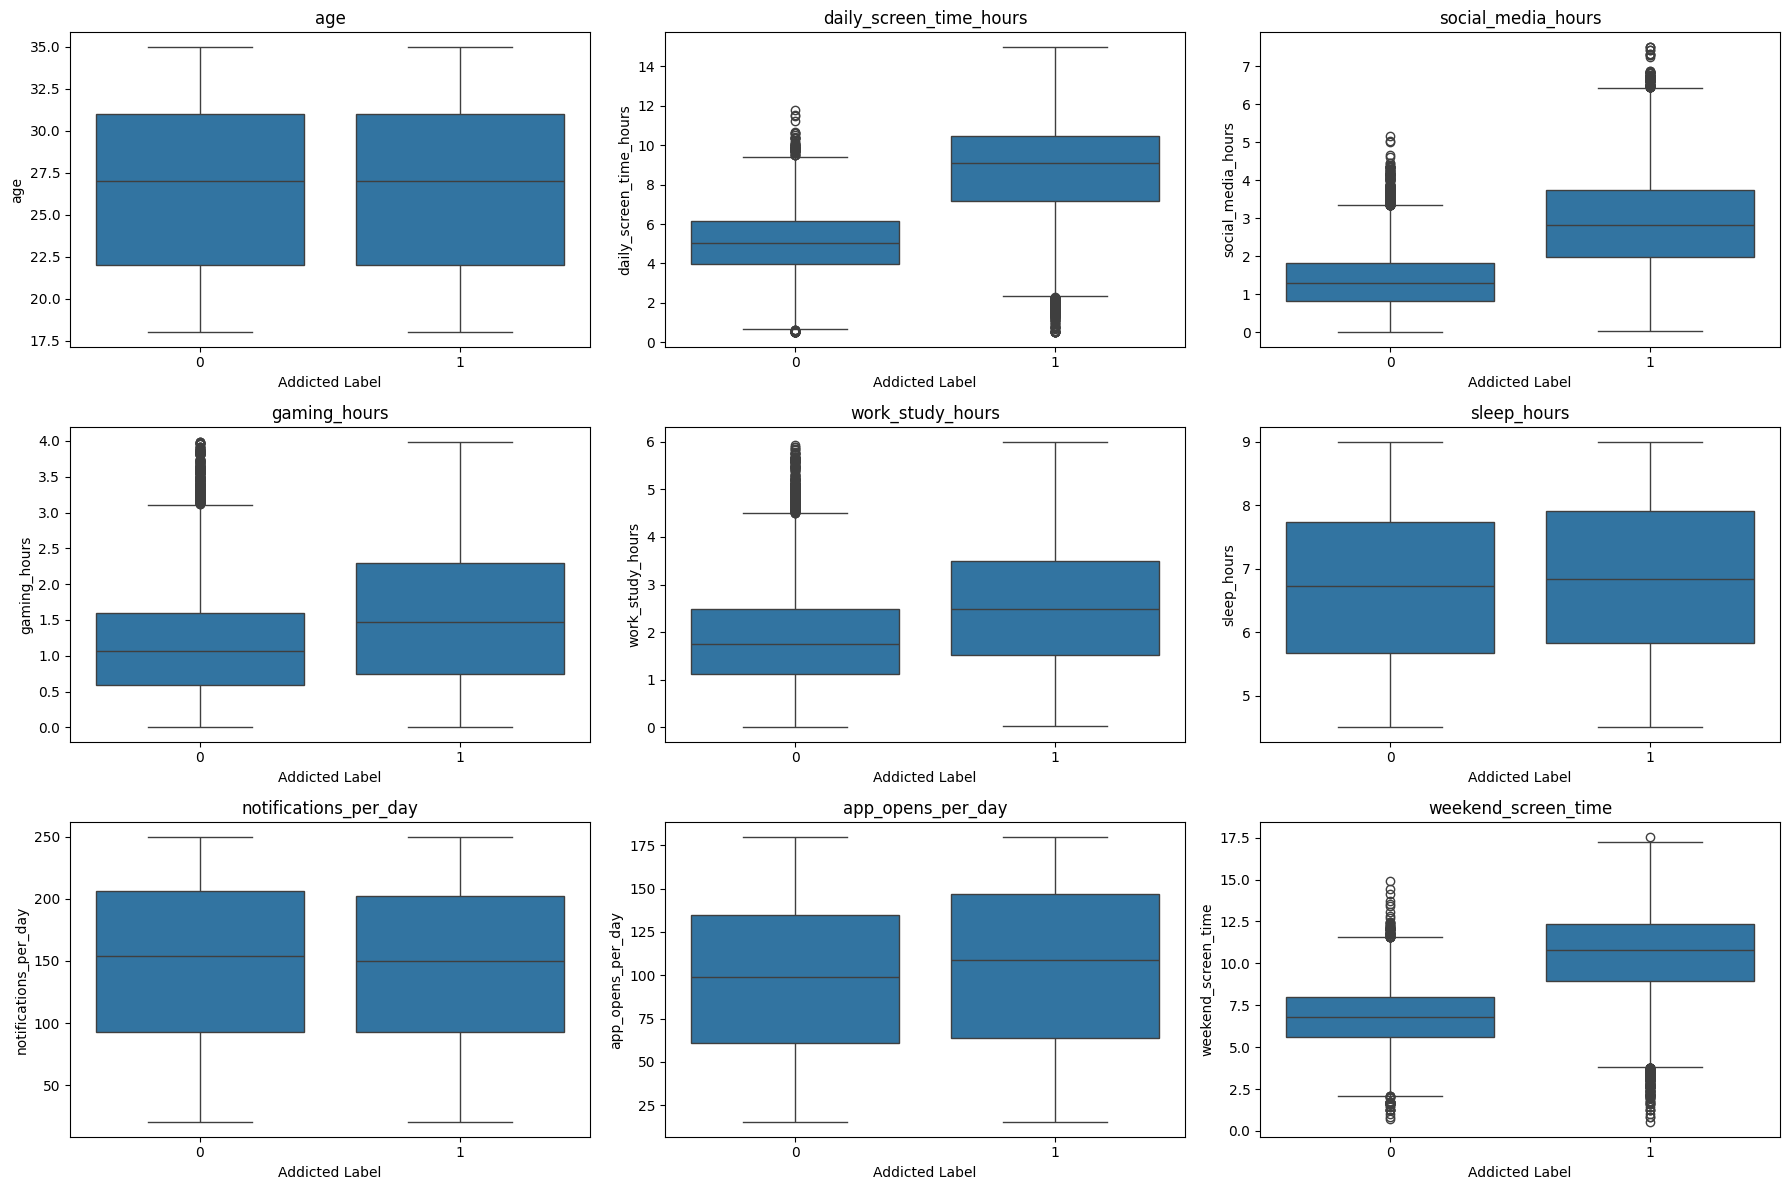

In [220]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time"
]

# Sample data for faster plotting
plot_data = train.sample(
    n=min(100000, len(train)),
    random_state=42
)

plt.figure(figsize=(18, 12))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    
    sns.boxplot(
        data=plot_data,
        x="addicted_label",
        y=col
    )
    
    plt.title(col)
    plt.xlabel("Addicted Label")

plt.tight_layout()
plt.show()

In [221]:
correlation_matrix = train[numerical_features + ["addicted_label"]].corr()

display(correlation_matrix.round(3))

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
age,1.000,0.013,0.011,0.002,0.001,0.002,-0.007,0.001,0.013,0.004
daily_screen_time_hours,0.013,1.000,0.596,0.429,0.526,0.028,0.005,0.055,0.800,0.611
social_media_hours,0.011,0.596,1.000,0.088,0.101,0.018,-0.012,0.048,0.478,0.532
gaming_hours,0.002,0.429,0.088,1.000,0.049,0.023,0.019,0.021,0.342,0.205
work_study_hours,0.001,0.526,0.101,0.049,1.000,-0.001,-0.012,0.009,0.418,0.251
sleep_hours,0.002,0.028,0.018,0.023,-0.001,1.000,0.026,0.024,0.028,0.043
notifications_per_day,-0.007,0.005,-0.012,0.019,-0.012,0.026,1.000,0.012,-0.003,-0.012
app_opens_per_day,0.001,0.055,0.048,0.021,0.009,0.024,0.012,1.000,0.046,0.063
weekend_screen_time,0.013,0.800,0.478,0.342,0.418,0.028,-0.003,0.046,1.000,0.590
addicted_label,0.004,0.611,0.532,0.205,0.251,0.043,-0.012,0.063,0.590,1.000


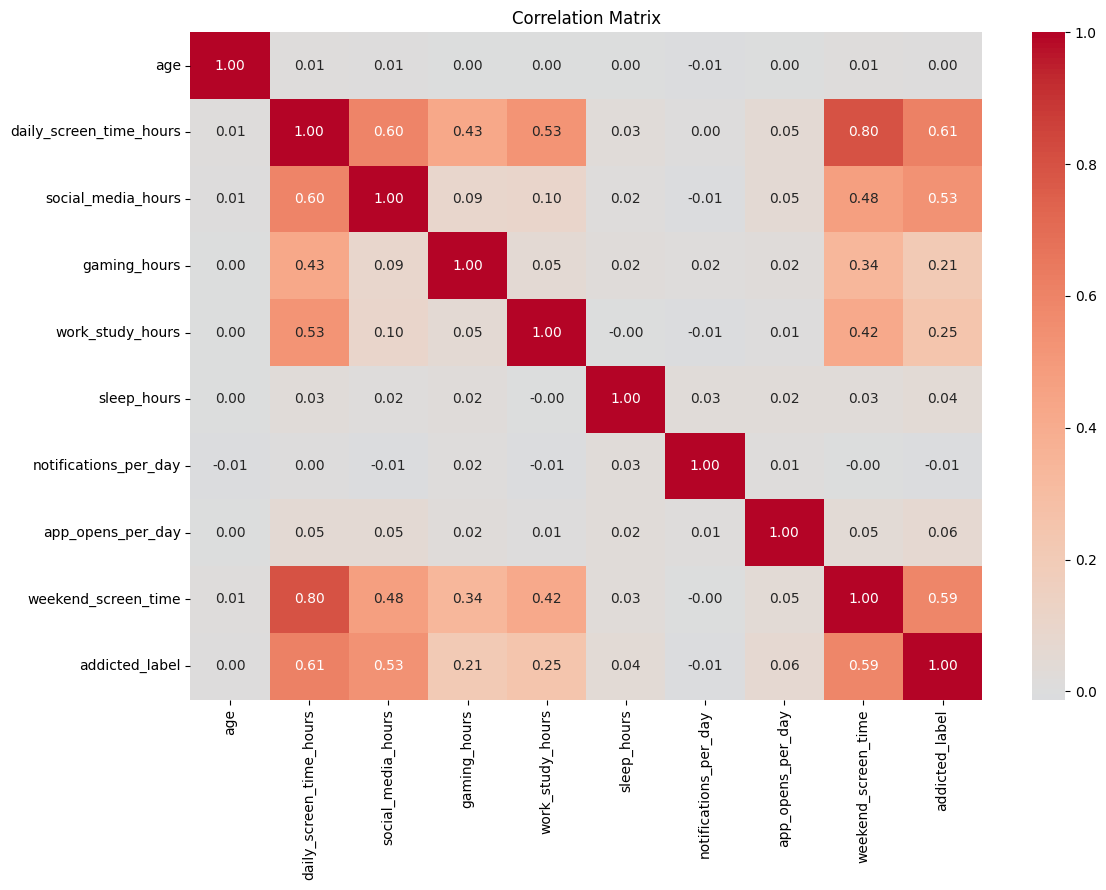

In [222]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [223]:
categorical_features = [
    "gender",
    "stress_level",
    "academic_work_impact"
]

for col in categorical_features:
    print(f"\n{'='*60}")
    print(f"{col}")
    print(f"{'='*60}")
    
    summary = (
        train.groupby(col, dropna=False)["addicted_label"]
        .agg(["count", "mean"])
    )
    
    summary["addiction_percentage"] = summary["mean"] * 100
    
    display(summary)


gender


,count,mean,addiction_percentage
gender,,,
Female,221595,0.703838,70.383808
Male,223662,0.723198,72.319840
Other,217078,0.701020,70.101991
NaN,29034,0.708790,70.878969



stress_level


,count,mean,addiction_percentage
stress_level,,,
High,220873,0.711431,71.143146
Low,207783,0.711160,71.116020
Medium,207565,0.705663,70.566329
NaN,55148,0.709001,70.900123



academic_work_impact


,count,mean,addiction_percentage
academic_work_impact,,,
No,316579,0.711029,71.102947
Yes,330566,0.707883,70.788284
NaN,44224,0.709456,70.945640


In [224]:
pd.crosstab(
    pd.qcut(train["daily_screen_time_hours"], q=10, duplicates="drop"),
    train["addicted_label"],
    normalize="index"
).round(3)

addicted_label,0,1
daily_screen_time_hours,,
"(0.499, 3.97]",0.735,0.265
"(3.97, 4.96]",0.690,0.310
"(4.96, 5.89]",0.601,0.399
"(5.89, 6.8]",0.466,0.534
"(6.8, 7.77]",0.277,0.723
"(7.77, 8.7]",0.105,0.895
"(8.7, 9.47]",0.026,0.974
"(9.47, 10.25]",0.005,0.995
"(10.25, 11.24]",0.001,0.999


In [225]:
pd.crosstab(
    pd.qcut(
        train["weekend_screen_time"],
        q=10,
        duplicates="drop"
    ),
    train["addicted_label"],
    normalize="index"
).round(3)

addicted_label,0,1
weekend_screen_time,,
"(0.509, 5.63]",0.736,0.264
"(5.63, 6.76]",0.678,0.322
"(6.76, 7.73]",0.604,0.396
"(7.73, 8.68]",0.427,0.573
"(8.68, 9.58]",0.254,0.746
"(9.58, 10.47]",0.132,0.868
"(10.47, 11.33]",0.051,0.949
"(11.33, 12.08]",0.012,0.988
"(12.08, 13.19]",0.002,0.998


In [226]:
pd.crosstab(
    pd.qcut(
        train["social_media_hours"],
        q=10,
        duplicates="drop"
    ),
    train["addicted_label"],
    normalize="index"
).round(3)

addicted_label,0,1
social_media_hours,,
"(-0.001, 0.85]",0.750,0.250
"(0.85, 1.27]",0.662,0.338
"(1.27, 1.62]",0.521,0.479
"(1.62, 1.94]",0.368,0.632
"(1.94, 2.31]",0.271,0.729
"(2.31, 2.7]",0.169,0.831
"(2.7, 3.16]",0.100,0.900
"(3.16, 3.65]",0.040,0.960
"(3.65, 4.33]",0.015,0.985


In [227]:
temp = train[
    ["daily_screen_time_hours",
     "social_media_hours",
     "addicted_label"]
].dropna()

temp["screen_bin"] = pd.qcut(
    temp["daily_screen_time_hours"],
    q=5,
    duplicates="drop"
)

temp["social_bin"] = pd.qcut(
    temp["social_media_hours"],
    q=5,
    duplicates="drop"
)

pivot = pd.pivot_table(
    temp,
    values="addicted_label",
    index="screen_bin",
    columns="social_bin",
    aggfunc="mean",
    observed=False
)

display(pivot.round(3))

social_bin,"(-0.001, 1.27]","(1.27, 1.94]","(1.94, 2.7]","(2.7, 3.65]","(3.65, 8.0]"
screen_bin,,,,,
"(0.499, 4.97]",0.113,0.440,0.631,0.723,0.829
"(4.97, 6.8]",0.138,0.296,0.637,0.791,0.910
"(6.8, 8.69]",0.548,0.618,0.775,0.912,0.975
"(8.69, 10.25]",0.962,0.968,0.975,0.987,0.998
"(10.25, 15.0]",0.999,0.999,0.998,0.999,1.000


In [228]:
print("Duplicate complete rows in train:", train.duplicated().sum())

print(
    "Duplicate feature rows excluding id and target:",
    train.drop(columns=["id", "addicted_label"]).duplicated().sum()
)

print("Duplicate IDs in train:", train["id"].duplicated().sum())
print("Duplicate IDs in test:", test["id"].duplicated().sum())

Duplicate complete rows in train: 0
Duplicate feature rows excluding id and target: 0
Duplicate IDs in train: 0
Duplicate IDs in test: 0


In [229]:
for col in numerical_features:
    print(f"\n{'='*60}")
    print(col)
    print(f"{'='*60}")
    
    print(train[col].quantile([
        0.001,
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
        0.999
    ]))


age
0.001    18.0
0.010    18.0
0.050    18.0
0.100    19.0
0.250    22.0
0.500    27.0
0.750    31.0
0.900    34.0
0.950    35.0
0.990    35.0
0.999    35.0
Name: age, dtype: float64

daily_screen_time_hours
0.001     0.95
0.010     2.03
0.050     3.19
0.100     3.97
0.250     5.48
0.500     7.77
0.750     9.84
0.900    11.24
0.950    11.71
0.990    12.68
0.999    13.66
Name: daily_screen_time_hours, dtype: float64

social_media_hours
0.001    0.04
0.010    0.22
0.050    0.58
0.100    0.85
0.250    1.45
0.500    2.31
0.750    3.37
0.900    4.33
0.950    4.86
0.990    5.71
0.999    6.51
Name: social_media_hours, dtype: float64

gaming_hours
0.001    0.01
0.010    0.05
0.050    0.18
0.100    0.32
0.250    0.70
0.500    1.33
0.750    2.09
0.900    2.80
0.950    3.21
0.990    3.83
0.999    3.97
Name: gaming_hours, dtype: float64

work_study_hours
0.001    0.17
0.010    0.37
0.050    0.63
0.100    0.84
0.250    1.36
0.500    2.20
0.750    3.20
0.900    4.15
0.950    4.71
0.990    5.67
0.9

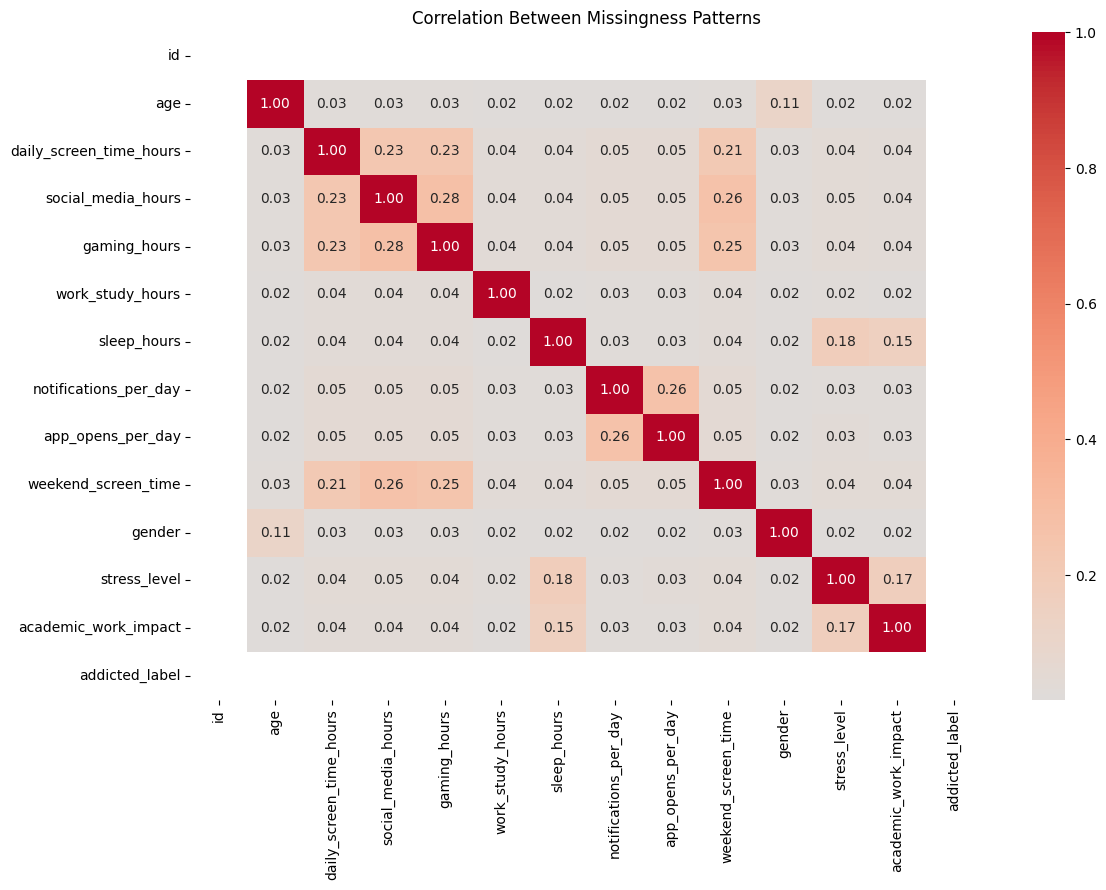

In [230]:
missing_corr = train.isna().corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    missing_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Missingness Patterns")
plt.tight_layout()
plt.show()

In [231]:
import sklearn
print("scikit-learn:", sklearn.__version__)

try:
    import xgboost
    print("xgboost:", xgboost.__version__)
except:
    print("xgboost not available")

try:
    import lightgbm
    print("lightgbm:", lightgbm.__version__)
except:
    print("lightgbm not available")

try:
    import catboost
    print("catboost:", catboost.__version__)
except:
    print("catboost not available")

scikit-learn: 1.6.1
xgboost: 3.2.0
lightgbm: 4.6.0
catboost: 1.2.10


In [232]:
non_negative_features = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time"
]

negative_counts = train[non_negative_features].lt(0).sum()

print("Negative values in TRAIN:")
display(negative_counts)

Negative values in TRAIN:


age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
dtype: int64

In [233]:
print("Negative values in TEST:")
display(test[non_negative_features].lt(0).sum())

Negative values in TEST:


age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
dtype: int64

In [234]:
expected_ranges = {
    "age": (18, 35),
    "daily_screen_time_hours": (0.5, 15),
    "social_media_hours": (0, 8),
    "gaming_hours": (0, 4),
    "work_study_hours": (0, 6),
    "sleep_hours": (4.5, 9),
    "notifications_per_day": (20, 250),
    "app_opens_per_day": (15, 180),
    "weekend_screen_time": (0.5, 17.56)
}

for col, (lower, upper) in expected_ranges.items():
    train_invalid = (
        (train[col] < lower) |
        (train[col] > upper)
    ).sum()

    test_invalid = (
        (test[col] < lower) |
        (test[col] > upper)
    ).sum()

    print(
        f"{col:30s} "
        f"Train invalid: {train_invalid:6d} | "
        f"Test invalid: {test_invalid:6d}"
    )

age                            Train invalid:      0 | Test invalid:      0
daily_screen_time_hours        Train invalid:      0 | Test invalid:      0
social_media_hours             Train invalid:      0 | Test invalid:      0
gaming_hours                   Train invalid:      0 | Test invalid:      0
work_study_hours               Train invalid:      0 | Test invalid:      0
sleep_hours                    Train invalid:      0 | Test invalid:      0
notifications_per_day          Train invalid:      0 | Test invalid:      0
app_opens_per_day              Train invalid:      0 | Test invalid:      0
weekend_screen_time            Train invalid:      0 | Test invalid:      0


In [235]:
categorical_features = [
    "gender",
    "stress_level",
    "academic_work_impact"
]

for col in categorical_features:
    print(f"\n{'='*50}")
    print(col)
    print("TRAIN:")
    print(train[col].value_counts(dropna=False))

    print("\nTEST:")
    print(test[col].value_counts(dropna=False))


gender
TRAIN:
gender
Male      223662
Female    221595
Other     217078
NaN        29034
Name: count, dtype: int64

TEST:
gender
Male      95357
Female    94295
Other     92438
NaN       14212
Name: count, dtype: int64

stress_level
TRAIN:
stress_level
High      220873
Low       207783
Medium    207565
NaN        55148
Name: count, dtype: int64

TEST:
stress_level
High      95622
Low       90746
Medium    90308
NaN       19626
Name: count, dtype: int64

academic_work_impact
TRAIN:
academic_work_impact
Yes    330566
No     316579
NaN     44224
Name: count, dtype: int64

TEST:
academic_work_impact
Yes    138694
No     131887
NaN     25721
Name: count, dtype: int64


In [236]:
import numpy as np

print("Infinite values in TRAIN:")
display(
    np.isinf(train.select_dtypes(include=np.number)).sum()
)

print("Infinite values in TEST:")
display(
    np.isinf(test.select_dtypes(include=np.number)).sum()
)

Infinite values in TRAIN:


id                         0
age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
addicted_label             0
dtype: int64

Infinite values in TEST:


id                         0
age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
dtype: int64

In [237]:
print(train["addicted_label"].value_counts(dropna=False))
print("Unique target values:", train["addicted_label"].unique())
print("Target missing:", train["addicted_label"].isna().sum())

addicted_label
1    490474
0    200895
Name: count, dtype: int64
Unique target values: [1 0]
Target missing: 0


In [238]:
train["activity_hours_sum"] = (
    train["social_media_hours"]
    + train["gaming_hours"]
    + train["work_study_hours"]
)

display(
    train[
        [
            "daily_screen_time_hours",
            "social_media_hours",
            "gaming_hours",
            "work_study_hours",
            "activity_hours_sum"
        ]
    ].describe()
)

,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,activity_hours_sum
count,595515.000000,557374.000000,564548.000000,639851.000000,451825.000000
mean,7.640865,2.471038,1.459265,2.366971,6.295986
std,2.721446,1.316137,0.934552,1.258797,2.199842
min,0.500000,0.000000,0.000000,0.000000,0.010000
25%,5.480000,1.450000,0.700000,1.360000,4.630000
50%,7.770000,2.310000,1.330000,2.200000,6.250000
75%,9.840000,3.370000,2.090000,3.200000,7.960000
max,15.000000,8.000000,4.000000,6.000000,14.560000


In [239]:
activity_sum = (
    train["social_media_hours"]
    + train["gaming_hours"]
    + train["work_study_hours"]
)

comparison = pd.DataFrame({
    "daily_screen_time": train["daily_screen_time_hours"],
    "activity_sum": activity_sum
})

# Only rows where all four values are available
comparison_clean = comparison.dropna()

comparison_clean["difference"] = (
    comparison_clean["daily_screen_time"]
    - comparison_clean["activity_sum"]
)

display(comparison_clean["difference"].describe())

/tmp/ipykernel_58/3643913605.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comparison_clean["difference"] = (


count    421427.000000
mean          1.342654
std           1.480499
min           0.000000
25%           0.460000
50%           0.750000
75%           1.460000
max          11.530000
Name: difference, dtype: float64

In [240]:
print(
    "Rows where social + gaming + work/study > daily screen time:",
    (comparison_clean["difference"] < 0).sum()
)

print(
    "Percentage:",
    (comparison_clean["difference"] < 0).mean() * 100
)

Rows where social + gaming + work/study > daily screen time: 0
Percentage: 0.0


In [241]:
# Divide training IDs into 20 equal-sized ranges
train_id_analysis = train.copy()

train_id_analysis["id_bin"] = pd.qcut(
    train_id_analysis["id"],
    q=20,
    duplicates="drop"
)

id_target_analysis = (
    train_id_analysis
    .groupby("id_bin", observed=True)["addicted_label"]
    .agg(["count", "mean"])
)

id_target_analysis["mean"] *= 100

display(id_target_analysis)

,count,mean
id_bin,,
"(-0.001, 34568.4]",34569,70.476438
"(34568.4, 69136.8]",34568,70.935547
"(69136.8, 103705.2]",34569,70.690503
"(103705.2, 138273.6]",34568,71.065726
"(138273.6, 172842.0]",34569,71.147560
"(172842.0, 207410.4]",34568,71.091761
"(207410.4, 241978.8]",34568,70.976047
"(241978.8, 276547.2]",34569,71.034742
"(276547.2, 311115.6]",34568,71.051261


In [242]:
print(
    "Correlation between ID and target:",
    train["id"].corr(train["addicted_label"])
)

Correlation between ID and target: 0.0010974801968522791


In [243]:
important_features = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time"
]

id_feature_corr = train[
    ["id"] + important_features
].corr()["id"].drop("id").sort_values()

display(id_feature_corr)

gaming_hours              -0.002048
notifications_per_day     -0.001197
age                       -0.001002
sleep_hours               -0.000918
app_opens_per_day         -0.000494
work_study_hours           0.000283
daily_screen_time_hours    0.001297
weekend_screen_time        0.002387
social_media_hours         0.003168
Name: id, dtype: float64

In [244]:
import numpy as np
import pandas as pd

# Keep test IDs ONLY for the final Kaggle submission
test_ids = test["id"].copy()

# Drop ID from model features
X = train.drop(columns=["id", "addicted_label"])
y = train["addicted_label"]

X_test = test.drop(columns=["id"])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (691369, 13)
y shape: (691369,)
X_test shape: (296302, 12)


In [245]:
numerical_features = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time"
]

categorical_features = [
    "gender",
    "stress_level",
    "academic_work_impact"
]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 9
Categorical features: 3


In [246]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numerical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    )
])

In [247]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )
    )
])

In [248]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [249]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

print("\nTarget distribution:")
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))

Training: (553095, 13)
Validation: (138274, 13)

Target distribution:
addicted_label
1    0.709424
0    0.290576
Name: proportion, dtype: float64
addicted_label
1    0.709425
0    0.290575
Name: proportion, dtype: float64


In [250]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

print("Processed train shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)

Processed train shape: (553095, 29)
Processed validation shape: (138274, 29)


In [251]:
# ============================================================
# CATBOOST DATA PREPARATION
# ============================================================

X_cb = train.drop(columns=["id", "addicted_label"]).copy()
y_cb = train["addicted_label"].copy()

X_test_cb = test.drop(columns=["id"]).copy()

test_ids = test["id"].copy()

categorical_features = [
    "gender",
    "stress_level",
    "academic_work_impact"
]

# CatBoost requires categorical values to be strings.
# Replace categorical NaNs with an explicit category.
for col in categorical_features:
    X_cb[col] = X_cb[col].fillna("Missing").astype(str)
    X_test_cb[col] = X_test_cb[col].fillna("Missing").astype(str)

print("Training shape:", X_cb.shape)
print("Test shape:", X_test_cb.shape)

print("\nCategorical missing values:")
print(X_cb[categorical_features].isna().sum())

Training shape: (691369, 13)
Test shape: (296302, 12)

Categorical missing values:
gender                  0
stress_level            0
academic_work_impact    0
dtype: int64


In [252]:
from sklearn.model_selection import train_test_split

X_train_cb, X_val_cb, y_train_cb, y_val_cb = train_test_split(
    X_cb,
    y_cb,
    test_size=0.20,
    stratify=y_cb,
    random_state=42
)

In [253]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100,
    thread_count=-1,
    allow_writing_files=False
)

catboost_model.fit(
    X_train_cb,
    y_train_cb,
    cat_features=categorical_features,
    eval_set=(X_val_cb, y_val_cb),
    early_stopping_rounds=50
)

0:	test: 0.9088759	best: 0.9088759 (0)	total: 444ms	remaining: 3m 41s
100:	test: 0.9384662	best: 0.9384662 (100)	total: 42.6s	remaining: 2m 48s
200:	test: 0.9448340	best: 0.9448340 (200)	total: 1m 25s	remaining: 2m 6s
300:	test: 0.9491584	best: 0.9491584 (300)	total: 2m 7s	remaining: 1m 24s
400:	test: 0.9522937	best: 0.9522937 (400)	total: 2m 48s	remaining: 41.7s
499:	test: 0.9543516	best: 0.9543516 (499)	total: 3m 30s	remaining: 0us

bestTest = 0.9543515548
bestIteration = 499



CatBoostClassifier(allow_writing_files=False, depth=8, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [254]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

y_val_cb_prob = catboost_model.predict_proba(X_val_cb)[:, 1]
y_val_cb_pred = (y_val_cb_prob >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_val_cb, y_val_cb_pred))
print("ROC-AUC:", roc_auc_score(y_val_cb, y_val_cb_prob))

print("\nClassification Report:")
print(classification_report(y_val_cb, y_val_cb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_cb, y_val_cb_pred))

Accuracy: 0.8881785440502191
ROC-AUC: 0.9543515548135154

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.81     40179
           1       0.92      0.93      0.92     98095

    accuracy                           0.89    138274
   macro avg       0.87      0.86      0.86    138274
weighted avg       0.89      0.89      0.89    138274


Confusion Matrix:
[[31916  8263]
 [ 7199 90896]]


In [255]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier
import numpy as np
import time

# ------------------------------------------------------------
# 5-Fold Stratified Cross-Validation
# ------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_scores = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_cb, y_cb), 1
):

    print("\n" + "=" * 60)
    print(f"FOLD {fold}/5")
    print("=" * 60)

    X_fold_train = X_cb.iloc[train_idx]
    X_fold_val = X_cb.iloc[val_idx]

    y_fold_train = y_cb.iloc[train_idx]
    y_fold_val = y_cb.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=8,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=100,
        thread_count=-1,
        allow_writing_files=False
    )

    start_time = time.time()

    model.fit(
        X_fold_train,
        y_fold_train,
        cat_features=categorical_features,
        eval_set=(X_fold_val, y_fold_val),
        early_stopping_rounds=50
    )

    val_prob = model.predict_proba(X_fold_val)[:, 1]

    fold_auc = roc_auc_score(
        y_fold_val,
        val_prob
    )

    fold_scores.append(fold_auc)

    elapsed = time.time() - start_time

    print(f"\nFold {fold} ROC-AUC: {fold_auc:.6f}")
    print(f"Fold {fold} time: {elapsed / 60:.2f} minutes")


print("\n" + "=" * 60)
print("CROSS-VALIDATION RESULTS")
print("=" * 60)

for i, score in enumerate(fold_scores, 1):
    print(f"Fold {i}: {score:.6f}")

print(f"\nMean ROC-AUC: {np.mean(fold_scores):.6f}")
print(f"Std ROC-AUC:  {np.std(fold_scores):.6f}")


FOLD 1/5
0:	test: 0.9110518	best: 0.9110518 (0)	total: 478ms	remaining: 3m 58s
100:	test: 0.9388634	best: 0.9388634 (100)	total: 43.7s	remaining: 2m 52s
200:	test: 0.9448812	best: 0.9448812 (200)	total: 1m 26s	remaining: 2m 8s
300:	test: 0.9490803	best: 0.9490803 (300)	total: 2m 8s	remaining: 1m 24s
400:	test: 0.9520230	best: 0.9520230 (400)	total: 2m 49s	remaining: 42s
499:	test: 0.9541667	best: 0.9541667 (499)	total: 3m 31s	remaining: 0us

bestTest = 0.9541666985
bestIteration = 499


Fold 1 ROC-AUC: 0.954167
Fold 1 time: 3.55 minutes

FOLD 2/5
0:	test: 0.9084363	best: 0.9084363 (0)	total: 453ms	remaining: 3m 45s
100:	test: 0.9389872	best: 0.9389872 (100)	total: 42.8s	remaining: 2m 48s
200:	test: 0.9453229	best: 0.9453229 (200)	total: 1m 25s	remaining: 2m 7s
300:	test: 0.9495790	best: 0.9495790 (300)	total: 2m 8s	remaining: 1m 24s
400:	test: 0.9527323	best: 0.9527323 (400)	total: 2m 49s	remaining: 41.9s
499:	test: 0.9547773	best: 0.9547773 (499)	total: 3m 31s	remaining: 0us

bestTes

In [256]:
best_fold = np.argmax(fold_scores) + 1
best_auc = max(fold_scores)

print(f"Best Fold: {best_fold}")
print(f"Best ROC-AUC: {best_auc:.6f}")

Best Fold: 4
Best ROC-AUC: 0.956057


In [257]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from catboost import CatBoostClassifier

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Get the indices for the best fold
for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_cb, y_cb), 1
):
    if fold == best_fold:
        best_train_idx = train_idx
        best_val_idx = val_idx
        break

# Get best-fold data
X_best_train = X_cb.iloc[best_train_idx]
X_best_val = X_cb.iloc[best_val_idx]

y_best_train = y_cb.iloc[best_train_idx]
y_best_val = y_cb.iloc[best_val_idx]

# Train the model with the same parameters
best_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100,
    thread_count=-1,
    allow_writing_files=False
)

best_model.fit(
    X_best_train,
    y_best_train,
    cat_features=categorical_features,
    eval_set=(X_best_val, y_best_val),
    early_stopping_rounds=50
)

# Predictions
best_prob = best_model.predict_proba(X_best_val)[:, 1]
best_pred = (best_prob >= 0.5).astype(int)

# Metrics
accuracy = accuracy_score(y_best_val, best_pred)
precision = precision_score(y_best_val, best_pred)
recall = recall_score(y_best_val, best_pred)
f1 = f1_score(y_best_val, best_pred)
roc_auc = roc_auc_score(y_best_val, best_prob)

print("\n" + "=" * 50)
print(f"BEST FOLD: {best_fold}")
print("=" * 50)

print(f"Accuracy : {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall   : {recall:.6f}")
print(f"F1 Score : {f1:.6f}")
print(f"ROC-AUC  : {roc_auc:.6f}")

print("\nClassification Report:")
print(classification_report(y_best_val, best_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_best_val, best_pred))

0:	test: 0.9101796	best: 0.9101796 (0)	total: 465ms	remaining: 3m 52s
100:	test: 0.9401111	best: 0.9401111 (100)	total: 42.8s	remaining: 2m 48s
200:	test: 0.9466390	best: 0.9466390 (200)	total: 1m 25s	remaining: 2m 7s
300:	test: 0.9509592	best: 0.9509592 (300)	total: 2m 8s	remaining: 1m 24s
400:	test: 0.9538785	best: 0.9538785 (400)	total: 2m 50s	remaining: 42s
499:	test: 0.9560572	best: 0.9560572 (499)	total: 3m 32s	remaining: 0us

bestTest = 0.9560572094
bestIteration = 499


BEST FOLD: 4
Accuracy : 0.890963
Precision: 0.918573
Recall   : 0.928620
F1 Score : 0.923569
ROC-AUC  : 0.956057

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81     40179
           1       0.92      0.93      0.92     98095

    accuracy                           0.89    138274
   macro avg       0.87      0.86      0.87    138274
weighted avg       0.89      0.89      0.89    138274


Confusion Matrix:
[[32104  8075]
 [ 7002 91093]]


In [258]:
catboost_long = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100,
    thread_count=-1,
    allow_writing_files=False
)

catboost_long.fit(
    X_train_cb,
    y_train_cb,
    cat_features=categorical_features,
    eval_set=(X_val_cb, y_val_cb),
    early_stopping_rounds=100
)

0:	test: 0.9088759	best: 0.9088759 (0)	total: 457ms	remaining: 7m 36s
100:	test: 0.9384662	best: 0.9384662 (100)	total: 42.8s	remaining: 6m 20s
200:	test: 0.9448340	best: 0.9448340 (200)	total: 1m 25s	remaining: 5m 39s
300:	test: 0.9491584	best: 0.9491584 (300)	total: 2m 7s	remaining: 4m 55s
400:	test: 0.9522937	best: 0.9522937 (400)	total: 2m 48s	remaining: 4m 12s
500:	test: 0.9543941	best: 0.9543941 (500)	total: 3m 30s	remaining: 3m 29s
600:	test: 0.9560220	best: 0.9560220 (600)	total: 4m 12s	remaining: 2m 47s
700:	test: 0.9572276	best: 0.9572276 (700)	total: 4m 55s	remaining: 2m 5s
800:	test: 0.9580992	best: 0.9580996 (799)	total: 5m 37s	remaining: 1m 23s
900:	test: 0.9588272	best: 0.9588272 (900)	total: 6m 19s	remaining: 41.7s
999:	test: 0.9594583	best: 0.9594583 (999)	total: 7m 1s	remaining: 0us

bestTest = 0.9594582504
bestIteration = 999



CatBoostClassifier(allow_writing_files=False, depth=8, eval_metric='AUC', iterations=1000, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [259]:
y_prob_long = catboost_long.predict_proba(X_val_cb)[:, 1]

print("ROC-AUC:", roc_auc_score(y_val_cb, y_prob_long))
print("Best iteration:", catboost_long.get_best_iteration())
print("Best validation AUC:", catboost_long.get_best_score())

ROC-AUC: 0.9594582503655995
Best iteration: 999
Best validation AUC: {'learn': {'Logloss': 0.22830518388723822}, 'validation': {'Logloss': 0.23424091235985636, 'AUC': 0.9594582503655995}}


In [260]:
catboost_1500 = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100,
    thread_count=-1,
    allow_writing_files=False
)

catboost_1500.fit(
    X_train_cb,
    y_train_cb,
    cat_features=categorical_features,
    eval_set=(X_val_cb, y_val_cb),
    early_stopping_rounds=150
)

y_prob_1500 = catboost_1500.predict_proba(X_val_cb)[:, 1]

print("ROC-AUC:", roc_auc_score(y_val_cb, y_prob_1500))
print("Best iteration:", catboost_1500.get_best_iteration())
print("Best validation score:")
print(catboost_1500.get_best_score())

0:	test: 0.9088759	best: 0.9088759 (0)	total: 546ms	remaining: 13m 39s
100:	test: 0.9384662	best: 0.9384662 (100)	total: 43s	remaining: 9m 55s
200:	test: 0.9448340	best: 0.9448340 (200)	total: 1m 25s	remaining: 9m 12s
300:	test: 0.9491584	best: 0.9491584 (300)	total: 2m 7s	remaining: 8m 27s
400:	test: 0.9522937	best: 0.9522937 (400)	total: 2m 49s	remaining: 7m 43s
500:	test: 0.9543941	best: 0.9543941 (500)	total: 3m 30s	remaining: 7m
600:	test: 0.9560220	best: 0.9560220 (600)	total: 4m 12s	remaining: 6m 17s
700:	test: 0.9572276	best: 0.9572276 (700)	total: 4m 54s	remaining: 5m 36s
800:	test: 0.9580992	best: 0.9580996 (799)	total: 5m 36s	remaining: 4m 53s
900:	test: 0.9588272	best: 0.9588272 (900)	total: 6m 19s	remaining: 4m 11s
1000:	test: 0.9594590	best: 0.9594590 (1000)	total: 7m 1s	remaining: 3m 30s
1100:	test: 0.9599678	best: 0.9599678 (1100)	total: 7m 43s	remaining: 2m 48s
1200:	test: 0.9603817	best: 0.9603817 (1200)	total: 8m 25s	remaining: 2m 5s
1300:	test: 0.9607038	best: 0.960

In [261]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier
import numpy as np
import time

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_scores_1500 = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_cb, y_cb), 1
):

    print("\n" + "=" * 60)
    print(f"FOLD {fold}/5")
    print("=" * 60)

    X_fold_train = X_cb.iloc[train_idx]
    X_fold_val = X_cb.iloc[val_idx]

    y_fold_train = y_cb.iloc[train_idx]
    y_fold_val = y_cb.iloc[val_idx]

    model_1500 = CatBoostClassifier(
        iterations=1500,
        learning_rate=0.05,
        depth=8,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=300,
        thread_count=-1,
        allow_writing_files=False
    )

    start_time = time.time()

    model_1500.fit(
        X_fold_train,
        y_fold_train,
        cat_features=categorical_features
    )

    val_prob = model_1500.predict_proba(X_fold_val)[:, 1]

    fold_auc = roc_auc_score(
        y_fold_val,
        val_prob
    )

    fold_scores_1500.append(fold_auc)

    elapsed = time.time() - start_time

    print(f"\nFold {fold} ROC-AUC: {fold_auc:.6f}")
    print(f"Fold {fold} time: {elapsed / 60:.2f} minutes")


print("\n" + "=" * 60)
print("1500 ITERATION CV RESULTS")
print("=" * 60)

for i, score in enumerate(fold_scores_1500, 1):
    print(f"Fold {i}: {score:.6f}")

print(f"\nMean ROC-AUC: {np.mean(fold_scores_1500):.6f}")
print(f"Std ROC-AUC:  {np.std(fold_scores_1500):.6f}")


FOLD 1/5
0:	total: 445ms	remaining: 11m 7s
300:	total: 1m 55s	remaining: 7m 41s
600:	total: 3m 51s	remaining: 5m 45s
900:	total: 5m 46s	remaining: 3m 50s
1200:	total: 7m 41s	remaining: 1m 54s
1499:	total: 9m 43s	remaining: 0us

Fold 1 ROC-AUC: 0.961277
Fold 1 time: 9.74 minutes

FOLD 2/5
0:	total: 416ms	remaining: 10m 23s
300:	total: 1m 55s	remaining: 7m 41s
600:	total: 3m 49s	remaining: 5m 43s
900:	total: 5m 44s	remaining: 3m 48s
1200:	total: 7m 38s	remaining: 1m 54s
1499:	total: 9m 35s	remaining: 0us

Fold 2 ROC-AUC: 0.961719
Fold 2 time: 9.62 minutes

FOLD 3/5
0:	total: 417ms	remaining: 10m 24s
300:	total: 1m 55s	remaining: 7m 39s
600:	total: 3m 51s	remaining: 5m 45s
900:	total: 5m 45s	remaining: 3m 49s
1200:	total: 7m 40s	remaining: 1m 54s
1499:	total: 9m 35s	remaining: 0us

Fold 3 ROC-AUC: 0.962185
Fold 3 time: 9.62 minutes

FOLD 4/5
0:	total: 424ms	remaining: 10m 36s
300:	total: 1m 56s	remaining: 7m 43s
600:	total: 3m 49s	remaining: 5m 43s
900:	total: 5m 45s	remaining: 3m 49s
12

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import time

depth_results = {}

for depth in [10, 11, 12, 13, 14]:

    print("\n" + "=" * 60)
    print(f"TESTING DEPTH = {depth}")
    print("=" * 60)

    model_depth = CatBoostClassifier(
        iterations=1500,
        learning_rate=0.05,
        depth=depth,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=500,
        thread_count=-1,
        allow_writing_files=False
    )

    start = time.time()

    model_depth.fit(
        X_train_cb,
        y_train_cb,
        cat_features=categorical_features,
        eval_set=(X_val_cb, y_val_cb),
        early_stopping_rounds=150
    )

    val_prob = model_depth.predict_proba(X_val_cb)[:, 1]

    auc = roc_auc_score(
        y_val_cb,
        val_prob
    )

    best_iteration = model_depth.get_best_iteration()

    elapsed = (time.time() - start) / 60

    depth_results[depth] = {
        "AUC": auc,
        "Best Iteration": best_iteration,
        "Time": elapsed
    }

    print(f"\nDepth {depth}")
    print(f"ROC-AUC: {auc:.6f}")
    print(f"Best iteration: {best_iteration}")
    print(f"Time: {elapsed:.2f} minutes")


print("\n" + "=" * 60)
print("DEPTH EXPERIMENT RESULTS")
print("=" * 60)

for depth, result in depth_results.items():
    print(
        f"Depth {depth}: "
        f"AUC={result['AUC']:.6f}, "
        f"Best Iteration={result['Best Iteration']}"
    )


TESTING DEPTH = 10
0:	test: 0.9148077	best: 0.9148077 (0)	total: 608ms	remaining: 15m 10s
500:	test: 0.9566131	best: 0.9566131 (500)	total: 4m 49s	remaining: 9m 37s
1000:	test: 0.9607191	best: 0.9607191 (1000)	total: 9m 42s	remaining: 4m 50s
1499:	test: 0.9620720	best: 0.9620720 (1499)	total: 14m 42s	remaining: 0us

bestTest = 0.9620719679
bestIteration = 1499


Depth 10
ROC-AUC: 0.962072
Best iteration: 1499
Time: 14.75 minutes

TESTING DEPTH = 11
0:	test: 0.9175852	best: 0.9175852 (0)	total: 738ms	remaining: 18m 26s
